<a href="https://colab.research.google.com/github/Snigdha-saxena08/EEG-User-Authentication/blob/main/Brainwave_Authentication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving s01_ex01_s01.csv to s01_ex01_s01.csv


In [ ]:
!pip install numpy pandas scipy matplotlib


In [ ]:
import pandas as pd
import numpy as np

file_path = "s01_ex01_s01.csv"
df = pd.read_csv(file_path)

df.head()


,Unnamed: 0,P4,Cz,F8,T7
0,9000,0.363670,1.737014,-4.067892,0.381685
1,9001,1.431664,13.112759,1.608346,9.416291
2,9002,3.898135,18.654392,3.684386,15.530512
3,9003,5.212464,17.267150,-0.361015,14.671486
4,9004,4.956096,14.274596,-3.350014,11.456772


In [ ]:
eeg_data = df.iloc[:, 1:]  # Remove sample index
channels = eeg_data.columns
sfreq = 200  # Sampling frequency from README


In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)


In [ ]:
from scipy.signal import welch

def bandpower(data, sf, band):
    f, Pxx = welch(data, sf, nperseg=1024)
    band_idx = np.logical_and(f >= band[0], f <= band[1])
    return np.trapz(Pxx[band_idx], f[band_idx])


In [ ]:
def hjorth_parameters(signal):
    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)

    var0 = np.var(signal)
    var1 = np.var(first_deriv)
    var2 = np.var(second_deriv)

    activity = var0
    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / mobility

    return activity, mobility, complexity


In [ ]:
from scipy.stats import skew, kurtosis

feature_list = []

for ch in channels:
    signal = eeg_data[ch].values

    # Filter 1-40 Hz
    filtered = bandpass_filter(signal, 1, 40, sfreq)

    # Band Powers
    delta = bandpower(filtered, sfreq, (0.5, 4))
    theta = bandpower(filtered, sfreq, (4, 8))
    alpha = bandpower(filtered, sfreq, (8, 12))
    beta  = bandpower(filtered, sfreq, (12, 30))
    gamma = bandpower(filtered, sfreq, (30, 40))

    # Statistical Features
    mean_val = np.mean(filtered)
    std_val = np.std(filtered)
    var_val = np.var(filtered)
    skew_val = skew(filtered)
    kurt_val = kurtosis(filtered)

    # Hjorth Parameters
    activity, mobility, complexity = hjorth_parameters(filtered)

    feature_list.extend([
        delta, theta, alpha, beta, gamma,
        mean_val, std_val, var_val, skew_val, kurt_val,
        activity, mobility, complexity
    ])

feature_vector = np.array(feature_list)
print("Feature Vector Shape:", feature_vector.shape)


Feature Vector Shape: (52,)


/tmp/ipython-input-1230795769.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[band_idx], f[band_idx])


In [ ]:
np.save("Subject1_features.npy", feature_vector)



In [ ]:
!pip install numpy pandas scipy tqdm


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving auditory-evoked-potential-eeg-biometric-dataset-1.0.0.zip to auditory-evoked-potential-eeg-biometric-dataset-1.0.0.zip


In [ ]:
import zipfile

zip_path = "auditory-evoked-potential-eeg-biometric-dataset-1.0.0.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("eeg_dataset")

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
import os

for root, dirs, files in os.walk("eeg_dataset"):
    for d in dirs:
        print(os.path.join(root, d))


eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0
eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/WFDB_Files
eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/Segmented_Data
eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/Raw_Data
eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/Filtered_Data
eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/WFDB_Files/Segmented_Data
eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/WFDB_Files/Raw_Data
eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/WFDB_Files/Filtered_Data


In [ ]:
!pip install numpy pandas scipy tqdm


In [ ]:
import numpy as np
import pandas as pd
import os
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from tqdm import tqdm


In [ ]:
sfreq = 200  # From dataset README
window_size = 2   # 2 seconds
overlap = 1       # 50% overlap

samples_per_window = window_size * sfreq
step_size = (window_size - overlap) * sfreq


In [ ]:
def bandpass_filter(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)


In [ ]:
def bandpower(data, sf, band):
    f, Pxx = welch(data, sf, nperseg=256)
    idx = np.logical_and(f >= band[0], f <= band[1])
    return np.trapz(Pxx[idx], f[idx])


In [ ]:
def hjorth(signal):
    d1 = np.diff(signal)
    d2 = np.diff(d1)

    var0 = np.var(signal)
    var1 = np.var(d1)
    var2 = np.var(d2)

    activity = var0
    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / mobility

    return activity, mobility, complexity


In [ ]:
def extract_features(window):
    features = []

    for ch in range(window.shape[1]):
        sig = window[:, ch]

        delta = bandpower(sig, sfreq, (0.5, 4))
        theta = bandpower(sig, sfreq, (4, 8))
        alpha = bandpower(sig, sfreq, (8, 12))
        beta  = bandpower(sig, sfreq, (12, 30))
        gamma = bandpower(sig, sfreq, (30, 40))

        mean = np.mean(sig)
        std = np.std(sig)
        var = np.var(sig)
        sk = skew(sig)
        kurt = kurtosis(sig)

        activity, mobility, complexity = hjorth(sig)

        features.extend([
            delta, theta, alpha, beta, gamma,
            mean, std, var, sk, kurt,
            activity, mobility, complexity
        ])

    return features


In [ ]:
dataset_path = "eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/Segmented_Data"

In [ ]:
X = []
y_subject = []
y_experiment = []

for file in tqdm(os.listdir(dataset_path)):

    if file.endswith(".csv"):
        file_path = os.path.join(dataset_path, file)

        subject = file.split("_")[0]      # s01
        experiment = file.split("_")[1]   # ex01

        df = pd.read_csv(file_path)
        data = df.iloc[:, 1:].values  # Remove sample index

        # Filter 1–40 Hz
        for ch in range(data.shape[1]):
            data[:, ch] = bandpass_filter(data[:, ch], 1, 40, sfreq)

        # Sliding Window
        for start in range(0, len(data) - samples_per_window, step_size):
            window = data[start:start+samples_per_window]
            features = extract_features(window)

            X.append(features)
            y_subject.append(subject)
            y_experiment.append(experiment)

X = np.array(X)
y_subject = np.array(y_subject)
y_experiment = np.array(y_experiment)

print("Final Feature Shape:", X.shape)
print("Subjects:", len(np.unique(y_subject)))
print("Experiments:", len(np.unique(y_experiment)))

  0%|          | 0/241 [00:00<?, ?it/s]/tmp/ipython-input-3768100377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[idx], f[idx])
  0%|          | 1/241 [00:01<05:40,  1.42s/it]/tmp/ipython-input-3768100377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[idx], f[idx])
  1%|          | 2/241 [00:03<07:29,  1.88s/it]/tmp/ipython-input-3768100377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[idx], f[idx])
  1%|          | 3/241 [00:08<12:18,  3.10s/it]/tmp/ipython-input-3768100377.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[id

Final Feature Shape: (28475, 52)
Subjects: 20
Experiments: 8


In [ ]:
np.save("EEG_Features.npy", X)
np.save("Subject_Labels.npy", y_subject)
np.save("Experiment_Labels.npy", y_experiment)


In [ ]:
!pip install numpy pandas scipy scikit-learn tqdm

In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.signal import welch, butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_curve

In [ ]:
dataset_path = "eeg_dataset/Segmented Data"

sfreq = 200
window_size = 2
overlap = 1

samples_per_window = window_size * sfreq
step_size = (window_size - overlap) * sfreq

In [ ]:
def bandpass_filter(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

In [ ]:
def bandpower(signal, sf, band):
    freqs, psd = welch(signal, sf, nperseg=256)
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx])

In [ ]:
def extract_relative_band_features(window, sfreq=200):

    features = []

    for ch in range(window.shape[1]):

        sig = window[:, ch]

        total_power = bandpower(sig, sfreq, (0.5, 40))

        delta = bandpower(sig, sfreq, (0.5, 4)) / total_power
        theta = bandpower(sig, sfreq, (4, 8)) / total_power
        alpha = bandpower(sig, sfreq, (8, 12)) / total_power
        beta  = bandpower(sig, sfreq, (12, 30)) / total_power
        gamma = bandpower(sig, sfreq, (30, 40)) / total_power

        # log transform improves stability
        features.extend(np.log([delta, theta, alpha, beta, gamma] + 1e-8))

    return features

In [ ]:
def extract_relative_band_features(window, sfreq=200):

    features = []

    for ch in range(window.shape[1]):

        sig = window[:, ch]

        total_power = bandpower(sig, sfreq, (0.5, 40))

        delta = bandpower(sig, sfreq, (0.5, 4)) / total_power
        theta = bandpower(sig, sfreq, (4, 8)) / total_power
        alpha = bandpower(sig, sfreq, (8, 12)) / total_power
        beta  = bandpower(sig, sfreq, (12, 30)) / total_power
        gamma = bandpower(sig, sfreq, (30, 40)) / total_power

        # log transform improves stability
        band_powers = np.array([delta, theta, alpha, beta, gamma])
        features.extend(np.log(band_powers + 1e-8))

    return features

dataset_path = "eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/Segmented_Data"
X = []
y_subject = []
y_experiment = []

for file in tqdm(os.listdir(dataset_path)):

    if file.endswith(".csv"):

        file_path = os.path.join(dataset_path, file)
        df = pd.read_csv(file_path)

        subject = file.split("_")[0]
        experiment = file.split("_")[1]

        data = df.iloc[:, 1:].values

        # Filter 1–40 Hz
        for ch in range(data.shape[1]):
            data[:, ch] = bandpass_filter(data[:, ch], 1, 40, sfreq)

        # Sliding window
        for start in range(0, len(data) - samples_per_window, step_size):

            window = data[start:start+samples_per_window]

            features = extract_relative_band_features(window)

            X.append(features)
            y_subject.append(subject)
            y_experiment.append(experiment)

X = np.array(X)
y_subject = np.array(y_subject)
y_experiment = np.array(y_experiment)

print("Feature shape:", X.shape)

  0%|          | 0/241 [00:00<?, ?it/s]/tmp/ipython-input-1671687446.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
  0%|          | 1/241 [00:02<11:00,  2.75s/it]/tmp/ipython-input-1671687446.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
  1%|          | 2/241 [00:04<08:13,  2.06s/it]/tmp/ipython-input-1671687446.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
  1%|          | 3/241 [00:05<07:19,  1.85s/it]/tmp/ipython-input-1671687446.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.

Feature shape: (28475, 20)


In [ ]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis

sfreq = 200  # From dataset README
window_size = 2   # 2 seconds
overlap = 1       # 50% overlap

samples_per_window = window_size * sfreq
step_size = (window_size - overlap) * sfreq

def bandpass_filter(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def bandpower(signal, sf, band):
    freqs, psd = welch(signal, sf, nperseg=256)
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx])

def extract_relative_band_features(window, sfreq=200):

    features = []

    for ch in range(window.shape[1]):

        sig = window[:, ch]

        total_power = bandpower(sig, sfreq, (0.5, 40))

        delta = bandpower(sig, sfreq, (0.5, 4)) / total_power
        theta = bandpower(sig, sfreq, (4, 8)) / total_power
        alpha = bandpower(sig, sfreq, (8, 12)) / total_power
        beta  = bandpower(sig, sfreq, (12, 30)) / total_power
        gamma = bandpower(sig, sfreq, (30, 40)) / total_power

        # log transform improves stability
        band_powers = np.array([delta, theta, alpha, beta, gamma])
        features.extend(np.log(band_powers + 1e-8))

    return features

dataset_path = "eeg_dataset/auditory-evoked-potential-eeg-biometric-dataset-1.0.0/Segmented_Data"
X = []
y_subject = []
y_experiment = []

for file in tqdm(os.listdir(dataset_path)):

    if file.endswith(".csv"):

        file_path = os.path.join(dataset_path, file)
        df = pd.read_csv(file_path)

        subject = file.split("_")[0]
        experiment = file.split("_")[1]

        data = df.iloc[:, 1:].values

        # Filter 1–40 Hz
        for ch in range(data.shape[1]):
            data[:, ch] = bandpass_filter(data[:, ch], 1, 40, sfreq)

        # Sliding window
        for start in range(0, len(data) - samples_per_window, step_size):

            window = data[start:start+samples_per_window]

            features = extract_relative_band_features(window)

            X.append(features)
            y_subject.append(subject)
            y_experiment.append(experiment)

X = np.array(X)
y_subject = np.array(y_subject)
y_experiment = np.array(y_experiment)

print("Feature shape:", X.shape)

  0%|          | 0/241 [00:00<?, ?it/s]/tmp/ipython-input-1599839229.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
  0%|          | 1/241 [00:02<11:37,  2.91s/it]/tmp/ipython-input-1599839229.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
  1%|          | 2/241 [00:05<10:32,  2.65s/it]/tmp/ipython-input-1599839229.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
  1%|          | 3/241 [00:09<13:31,  3.41s/it]/tmp/ipython-input-1599839229.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return

Feature shape: (28475, 20)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
np.save("EEG_Band_Features.npy", X)
np.save("Subject_Labels.npy", y_subject)
np.save("Experiment_Labels.npy", y_experiment)

In [ ]:
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(28475, 20)


In [ ]:
import numpy as np
from scipy.linalg import logm

def extract_covariance_features(window):
    """
    window shape: (samples, channels)
    returns: flattened log-covariance vector
    """

    # Step 1: Compute covariance matrix (channels x channels)
    cov = np.cov(window.T)

    # Step 2: Regularization (important for stability)
    cov += 1e-6 * np.eye(cov.shape[0])

    # Step 3: Log-Euclidean mapping
    log_cov = logm(cov)

    # Step 4: Flatten
    return log_cov.flatten()

In [ ]:
# windows_list   # list of window arrays
print(y_subject)

['s10' 's10' 's10' ... 's09' 's09' 's09']


In [ ]:
# Regenerate windows_list from the raw data
windows_list = []

for file in tqdm(os.listdir(dataset_path)):

    if file.endswith(".csv"):
        file_path = os.path.join(dataset_path, file)
        df_local = pd.read_csv(file_path)
        data_local = df_local.iloc[:, 1:].values  # Remove sample index

        # Filter 1–40 Hz
        for ch in range(data_local.shape[1]):
            data_local[:, ch] = bandpass_filter(data_local[:, ch], 1, 40, sfreq)

        # Sliding window
        for start in range(0, len(data_local) - samples_per_window, step_size):
            window = data_local[start:start+samples_per_window]
            windows_list.append(window)

X_cov = []

for window in windows_list:
    feat = extract_covariance_features(window)
    X_cov.append(feat)

X_cov = np.array(X_cov)

print("Covariance Feature Shape:", X_cov.shape)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 6.058704781270734e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 6.342080428314929e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 6.097962148587228e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 6.756243529024889e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 5.344046102820459e-13
  return f(*

Covariance Feature Shape: (28475, 16)


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 4.599579325528343e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 5.956439775802206e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 5.564708353496147e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 5.327563348549224e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: RuntimeWarning: logm result may be inaccurate, approximate err = 6.217071358003431e-13
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

In [ ]:
import numpy as np
from scipy.linalg import eigh

def extract_covariance_features(window):

    # Step 1: Covariance
    cov = np.cov(window.T)

    # Step 2: Eigen decomposition
    eigvals, eigvecs = eigh(cov)

    # Step 3: Force positive eigenvalues
    eigvals[eigvals < 1e-6] = 1e-6

    # Step 4: Log of eigenvalues
    log_eigvals = np.log(eigvals)

    # Step 5: Reconstruct log-covariance
    log_cov = eigvecs @ np.diag(log_eigvals) @ eigvecs.T

    return log_cov.flatten()

In [ ]:
windows_list = []

for file in tqdm(os.listdir(dataset_path)):

    if file.endswith(".csv"):

        file_path = os.path.join(dataset_path, file)
        df_local = pd.read_csv(file_path)

        # Remove first column (sample index)
        data_local = df_local.iloc[:, 1:].values.astype(float)

        # Bandpass filter (1–40 Hz)
        for ch in range(data_local.shape[1]):
            data_local[:, ch] = bandpass_filter(
                data_local[:, ch], 1, 40, sfreq
            )

        # Sliding window
        for start in range(0, len(data_local) - samples_per_window, step_size):
            window = data_local[start:start+samples_per_window]
            windows_list.append(window)

100%|██████████| 241/241 [00:21<00:00, 11.30it/s]


In [ ]:
from scipy.linalg import eigh

def extract_covariance_features(window):

    cov = np.cov(window.T)

    # Eigen decomposition
    eigvals, eigvecs = eigh(cov)

    # Force positive eigenvalues
    eigvals[eigvals < 1e-6] = 1e-6

    # Log mapping
    log_eigvals = np.log(eigvals)

    log_cov = eigvecs @ np.diag(log_eigvals) @ eigvecs.T

    return log_cov.flatten()

In [ ]:
X_cov = []

for window in tqdm(windows_list):
    X_cov.append(extract_covariance_features(window))

X_cov = np.array(X_cov)

print("Covariance Feature Shape:", X_cov.shape)

100%|██████████| 28475/28475 [00:14<00:00, 1939.49it/s]

Covariance Feature Shape: (28475, 16)


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def compute_eer(y_true, scores):

    fpr, tpr, thresholds = roc_curve(y_true, scores)

    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    eer_threshold = interp1d(fpr, thresholds)(eer)

    return eer, fpr, 1 - tpr

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def evaluate_biometric_system(X, y_subject):

    subjects = np.unique(y_subject)
    eer_list = []

    for subject in subjects:

        # 1-vs-All labels
        y_binary = (y_subject == subject).astype(int)

        # Train/Test Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_binary,
            test_size=0.3,
            stratify=y_binary,
            random_state=42
        )

        # Standardization
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Linear SVM
        clf = SVC(kernel='linear')
        clf.fit(X_train, y_train)

        scores = clf.decision_function(X_test)

        eer, fpr, fnr = compute_eer(y_test, scores)

        eer_list.append(eer)

        print(f"Subject {subject} → EER: {eer:.4f}")

    print("\nAverage EER:", np.mean(eer_list))

    return eer_list, np.mean(eer_list)

In [ ]:
eer_cov, avg_eer_cov = evaluate_biometric_system(X_cov, y_subject)

Subject s01 → EER: 0.0309
Subject s02 → EER: 0.3386
Subject s03 → EER: 0.0264
Subject s04 → EER: 0.1321
Subject s05 → EER: 0.0757
Subject s06 → EER: 0.2188
Subject s07 → EER: 0.3365
Subject s08 → EER: 0.1200
Subject s09 → EER: 0.0896
Subject s10 → EER: 0.0894
Subject s11 → EER: 0.4718
Subject s12 → EER: 0.0965
Subject s13 → EER: 0.2233
Subject s14 → EER: 0.0609
Subject s15 → EER: 0.1529
Subject s16 → EER: 0.1388
Subject s17 → EER: 0.1060
Subject s18 → EER: 0.1224
Subject s19 → EER: 0.3073
Subject s20 → EER: 0.0609

Average EER: 0.15993577232096245


In [ ]:
eer_band, avg_eer_band = evaluate_biometric_system(X, y_subject)

Subject s01 → EER: 0.2853
Subject s02 → EER: 0.1106
Subject s03 → EER: 0.1388
Subject s04 → EER: 0.2400
Subject s05 → EER: 0.1425
Subject s06 → EER: 0.3506
Subject s07 → EER: 0.5059
Subject s08 → EER: 0.2338
Subject s09 → EER: 0.1551
Subject s10 → EER: 0.1129
Subject s11 → EER: 0.4376
Subject s12 → EER: 0.3401
Subject s13 → EER: 0.1346
Subject s14 → EER: 0.2486
Subject s15 → EER: 0.4380
Subject s16 → EER: 0.0729
Subject s17 → EER: 0.1647
Subject s18 → EER: 0.2237
Subject s19 → EER: 0.1368
Subject s20 → EER: 0.1535

Average EER: 0.2313105180697908


In [ ]:
print("Average EER (Band Features):", avg_eer_band)
print("Average EER (Covariance Features):", avg_eer_cov)

Average EER (Band Features): 0.2313105180697908
Average EER (Covariance Features): 0.15993577232096245


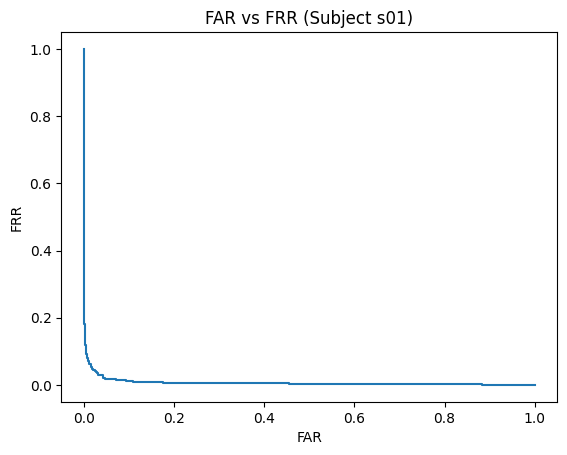

EER: 0.030918945553285764


In [ ]:
import matplotlib.pyplot as plt

# Example: Subject 1
subject = 's01' # Changed from 1 to 's01'
y_binary = (y_subject == subject).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_cov, y_binary, test_size=0.3, stratify=y_binary, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

scores = clf.decision_function(X_test)

eer, fpr, fnr = compute_eer(y_test, scores)

plt.plot(fpr, fnr)
plt.xlabel("FAR")
plt.ylabel("FRR")
plt.title(f"FAR vs FRR (Subject {subject})")
plt.show()

print("EER:", eer)

In [ ]:
X_hybrid = np.concatenate([X, X_cov], axis=1)

print("Hybrid Shape:", X_hybrid.shape)

Hybrid Shape: (28475, 36)


In [ ]:
!pip install pyriemann

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 2.7 MB/s eta 0:00:00


In [ ]:
from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# Step 1: Compute covariance matrices (not log-flattened)
cov_matrices = []

for window in windows_list:
    cov = np.cov(window.T)
    cov += 1e-6 * np.eye(cov.shape[0])
    cov_matrices.append(cov)

cov_matrices = np.array(cov_matrices)

print("Cov matrix shape:", cov_matrices.shape)

Cov matrix shape: (28475, 4, 4)


In [ ]:
# Compute Riemannian mean
mean_cov = mean_covariance(cov_matrices, metric='riemann')

# Project to tangent space
ts = TangentSpace(metric='riemann')
X_tangent = ts.fit_transform(cov_matrices)

print("Tangent Feature Shape:", X_tangent.shape)

Tangent Feature Shape: (28475, 10)


In [ ]:
import re

y_experiment_numeric = np.array([int(re.search(r'\d+', e).group()) for e in y_experiment]) # Extract digits robustly

train_mask = y_experiment_numeric <= 6
test_mask  = y_experiment_numeric > 6

X_train = X_tangent[train_mask]
X_test  = X_tangent[test_mask]

y_train = y_subject[train_mask]
y_test  = y_subject[test_mask]

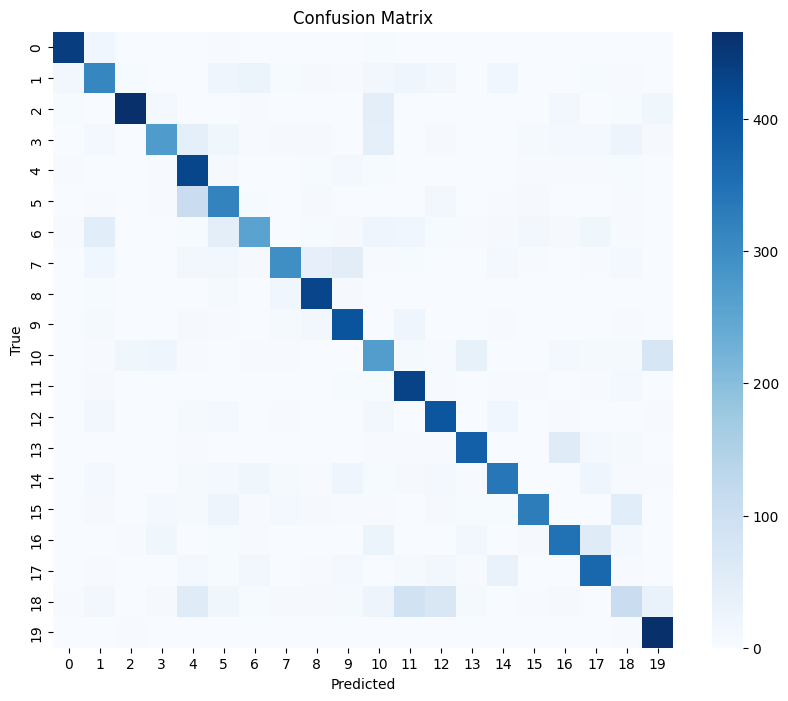

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

clf = SVC(kernel='rbf')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
eer_tangent, avg_eer_tangent = evaluate_biometric_system(X_tangent, y_subject)
eer_hybrid, avg_eer_hybrid = evaluate_biometric_system(X_hybrid, y_subject)

results = {
    "Feature Type": ["Band", "Covariance (Log)", "Riemannian Tangent", "Hybrid"],
    "Average EER": [
        avg_eer_band,
        avg_eer_cov,
        avg_eer_tangent,
        avg_eer_hybrid
    ]
}

df_results = pd.DataFrame(results)
print(df_results)

Subject s01 → EER: 0.0329
Subject s02 → EER: 0.1953
Subject s03 → EER: 0.0286
Subject s04 → EER: 0.1271
Subject s05 → EER: 0.0762
Subject s06 → EER: 0.2037
Subject s07 → EER: 0.1953
Subject s08 → EER: 0.1224
Subject s09 → EER: 0.0871
Subject s10 → EER: 0.0905
Subject s11 → EER: 0.4047
Subject s12 → EER: 0.0941
Subject s13 → EER: 0.1835
Subject s14 → EER: 0.0612
Subject s15 → EER: 0.2177
Subject s16 → EER: 0.1365
Subject s17 → EER: 0.1017
Subject s18 → EER: 0.1192
Subject s19 → EER: 0.3396
Subject s20 → EER: 0.0632

Average EER: 0.14402765916943447
Subject s01 → EER: 0.0282
Subject s02 → EER: 0.0588
Subject s03 → EER: 0.0242
Subject s04 → EER: 0.0635
Subject s05 → EER: 0.0282
Subject s06 → EER: 0.1388
Subject s07 → EER: 0.1686
Subject s08 → EER: 0.0776
Subject s09 → EER: 0.0447
Subject s10 → EER: 0.0400
Subject s11 → EER: 0.1624
Subject s12 → EER: 0.0505
Subject s13 → EER: 0.0626
Subject s14 → EER: 0.0329
Subject s15 → EER: 0.0675
Subject s16 → EER: 0.0156
Subject s17 → EER: 0.0766
Subj

In [ ]:
X_final = X_hybrid
y_final = y_subject

In [ ]:
train_mask = y_experiment_numeric <= 6
test_mask  = y_experiment_numeric > 6

X_train = X_final[train_mask]
X_test  = X_final[test_mask]

y_train = y_final[train_mask]
y_test  = y_final[test_mask]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [ ]:
# Linear SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

print("Linear SVM Accuracy:", acc_linear)

Linear SVM Accuracy: 0.8446977619744823


In [ ]:
# RBF SVM
svm_rbf = SVC(kernel='rbf', C=10, gamma='scale')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("RBF SVM Accuracy:", acc_rbf)

RBF SVM Accuracy: 0.8713658230495712


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8225266680610751


In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.8072578958376908


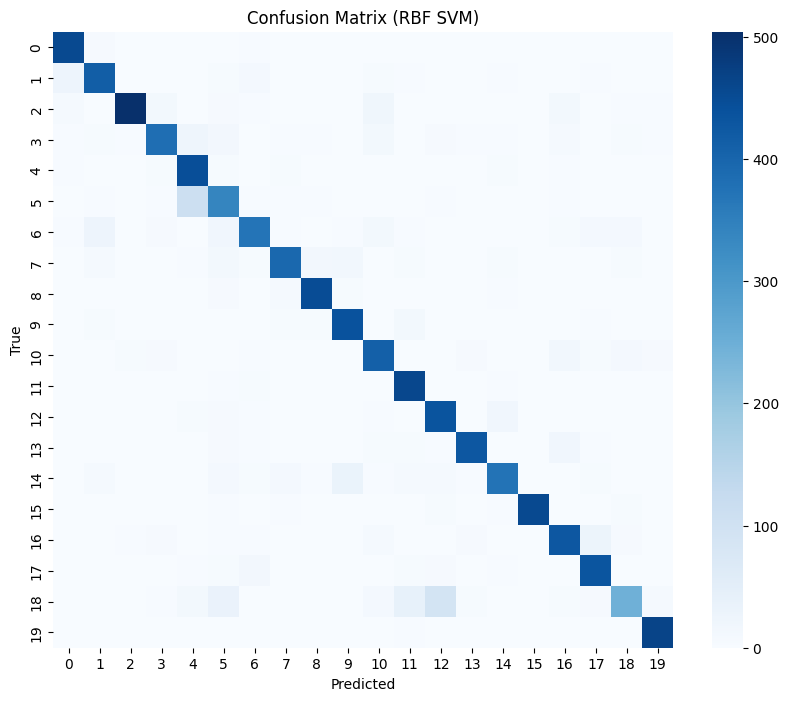

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix (RBF SVM)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
import pandas as pd

results = {
    "Model": ["Linear SVM", "RBF SVM", "Random Forest", "KNN"],
    "Accuracy": [acc_linear, acc_rbf, acc_rf, acc_knn]
}

df_results = pd.DataFrame(results)
print(df_results)


           Model  Accuracy
0     Linear SVM  0.844698
1        RBF SVM  0.871366
2  Random Forest  0.822527
3            KNN  0.807258
